In [5]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

%matplotlib inline

import csv
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
from csv_reader import read_csv
from aux import set_smallest_n_zero
from disp import set_font_size, get_ordered_colors
from copy import deepcopy as copy
from analysis_tools import *
from pathlib import Path
from csv_reader import read_csv
from csv_writer import write_csv
import glob
from scipy import stats

FONT_SIZE = 26
NON_LABEL_FONT_SIZE = 22

new_rc_params = {
    'text.usetex': False,
    "svg.fonttype": 'none'
}

matplotlib.rcParams.update(new_rc_params)

plt.rcParams['font.family'] = ['Helvetica']
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 3.0

warnings.filterwarnings('ignore')

rule_names = [ # Define labels for all rules to be run during simulations
    r'Const',
    r'$y$',
    r'$x$',
    r'$x \, y$',
    r'$y_{int}$',
    r'$x \, y_{int}$',
    r'$x_{int}$',
    r'$x_{int} \, y$',
    r'$y_{int} \, y$',
    r'$x_{int} \, x$',

    r'$w$',
    r'$w \, y$',
    r'$w \, x$',
    r'$w \, x \, y$',
    r'$w y_{int}$',
    r'$w x \, y_{int}$',
    r'$w x_{int}$',
    r'$w x_{int} \, y$',
    r'$w y_{int} \, y$',
    r'$w x_{int} \, x$',
]

time_constants = [
    r'$\tau \, y_{int}$',
    r'$\tau \, x \, y_{int}$',
    r'$\tau \, x_{int}$',
    r'$\tau \, x_{int} \, y$',
    r'$\tau \, y_{int} \, y$',
    r'$\tau \, x_{int} \, x$',
    
    r'$\tau \, w y_{int}$',
    r'$\tau \, w x \, y_{int}$',
    r'$\tau \, w x_{int}$',
    r'$\tau \, w x_{int} \, y$',
    r'$\tau \, w y_{int} \, y$',
    r'$\tau \, w x_{int} \, x$',
]

general_rule_names = copy(rule_names)

rule_names = [
    [r'$E \rightarrow E$ ' + r_name for r_name in rule_names],
    [r'$E \rightarrow I$ ' + r_name for r_name in rule_names],
    [r'$I \rightarrow E$ ' + r_name for r_name in rule_names],
]
rule_names = np.array(rule_names).flatten()

# print(matplotlib.font_manager.findfont('Helvetica'))
# flist = matplotlib.font_manager.get_fontconfig_fonts()
# names = [matplotlib.font_manager.FontProperties(fname=fname).get_name() for fname in flist]
# print(names)

# Evaluating learned rules against a test set and dropping out terms to determine importantance

In [62]:
def plot_scores(file_names, ctrl_file_name):
    plt.rcParams['axes.linewidth'] = 3.0
    
    scale = 1
    fig, ax = plt.subplots(figsize=(1 * scale, 2 * scale), tight_layout=True)
    
    rule_score_medians = []
    
    for file_name in file_names:
        train_data_path = f'./sims_out/{file_name}/train_data.csv'
        df_train = read_csv(train_data_path, read_header=False, start=1)
        scores = df_train[df_train.columns[-1]]
        
        ax.scatter(
            np.random.normal(loc=0, scale=0.1, size=1),
            np.median(scores),
            facecolor='None',
            edgecolor='#1F449C',
            s=40,
        )
        
        rule_score_medians.append(np.median(scores))
    
    print(np.mean(rule_score_medians))


    ctrl_train_data_path = f'./sims_out/{ctrl_file_name}/train_data.csv'
    df_train = read_csv(ctrl_train_data_path, read_header=False, start=1)
    scores = df_train[df_train.columns[-1]]
    
    print(np.median(scores))
    
    ax.plot(
        [-0.5, 0.5],
        np.median(scores) * np.ones(2),
        '--',
        c='grey',
    )
        

    set_font_size(ax, FONT_SIZE, non_label_font_size=NON_LABEL_FONT_SIZE)
    
    ax.set_ylim(0, 1.1)
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylabel(r'$R^2$')
    ax.set_xticks([])

    fig.savefig(os.path.join('./figures/unperturbed_scores.png'))
    fig.savefig(os.path.join('./figures/unperturbed_scores.svg'))

0.9648368348368966
0.6617595639707754


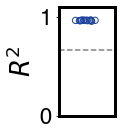

In [63]:
file_names = [
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_18:55:13.790766',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_18:55:34.464308',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_18:55:34.464422',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_18:55:34.464425',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_18:55:34.464429',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_18:55:34.466462',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_18:55:34.466625',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_18:55:34.467595',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_19:09:12.151103',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_19:10:09.173794',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_19:10:09.819661',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_19:10:43.281661',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_19:11:16.830820',
    'decoder_ee_test_scores_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_19:12:24.496905',
]
ctrl_file_name = 'decoder_ee_test_scores_ctrl_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.0_FRACI_0.75_SEED_500_2024-10-30_23:30:04.632131'

plot_scores(file_names, ctrl_file_name)